🚀 设备: cuda
Working with z of shape (1, 4, 64, 64, 64) = 1048576 dimensions.


C:\Users\qingy\AppData\Local\Temp\ipykernel_23220\2724378626.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(CKPT_PATH, map_location="cpu")


📂 正在读取 NIfTI 文件: data/BraTS2021/TrainingData/BraTS2021_00009/BraTS2021_00009_t1.nii.gz
   原始数据形状: (240, 240, 155)
   正在缩放: torch.Size([1, 1, 16, 240, 240]) -> [1, 1, 16, 256, 256]
⚡ 开始推理...
💾 保存结果...
🎉 验证完成！请查看 verify_brats_result.png
如果右图能看到大致的大脑轮廓，说明模型在真实数据上工作正常！


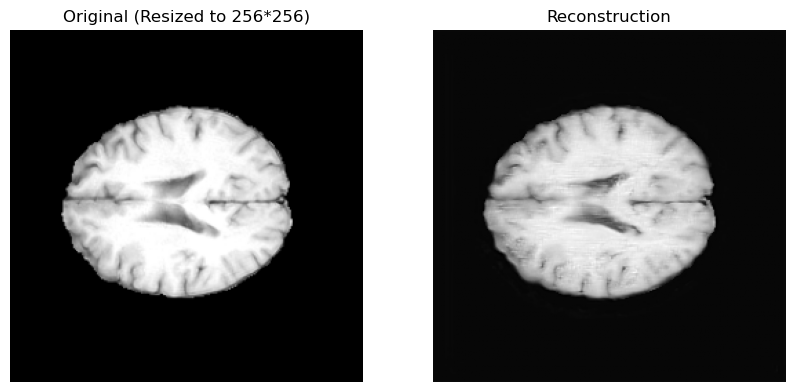

In [1]:
# 验证 VQGAN Stage 1 在真实 BraTS 医学影像数据上的重建效果

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import sys
import os

# ================= 用户配置区 =================
CKPT_PATH = "vqgan/stage1.ckpt"          # .ckpt 路径
NII_PATH = "data/BraTS2021/TrainingData/BraTS2021_00009/BraTS2021_00009_t1.nii.gz" # 你的真实 BraTS 数据路径
DEPTH_SLICES = 16  # 我们截取多少层切片输入给模型 (显存够大可以改大，比如 32)
TARGET_SIZE = 256   # 模型要求的输入分辨率
# ============================================

# 防止找不到 taming 模块
sys.path.append(os.getcwd()) 
try:
    from taming.modules.diffusionmodules.model import Encoder, Decoder
    from taming.modules.vqvae.quantize import VectorQuantizer2 as VectorQuantizer
except ImportError:
    print("❌ 找不到 taming 模块，请检查文件夹位置。")
    exit()

# --- 1. 定义模型 (和之前一样) ---
class Minimal3DVQModel(nn.Module):
    def __init__(self, ddconfig, n_embed, embed_dim):
        super().__init__()
        self.encoder = Encoder(**ddconfig)
        self.decoder = Decoder(**ddconfig)
        self.quantize = VectorQuantizer(n_embed, embed_dim, beta=0.25)
        self.quant_conv = nn.Conv3d(ddconfig["z_channels"], embed_dim, 1)
        self.post_quant_conv = nn.Conv3d(embed_dim, ddconfig["z_channels"], 1)

    def encode(self, x):
        h = self.encoder(x)
        h = self.quant_conv(h)
        quant, emb_loss, info = self.quantize(h)
        return quant

    def decode(self, quant):
        quant = self.post_quant_conv(quant)
        dec = self.decoder(quant)
        return dec

    def forward(self, x):
        quant = self.encode(x)
        dec = self.decode(quant)
        return dec

# --- 2. 专门处理医学影像的函数 ---
def load_and_preprocess_brats(filepath, target_depth=16, target_size=64):
    print(f"📂 正在读取 NIfTI 文件: {filepath}")
    # 读取数据
    try:
        img = nib.load(filepath)
        data = img.get_fdata() # 形状通常是 (H, W, D) -> (240, 240, 155)
    except Exception as e:
        print(f"❌ 读取失败: {e}")
        return None

    print(f"   原始数据形状: {data.shape}")

    # --- 步骤 A: 归一化 (关键) ---
    # 医学图像没有固定的范围，通常需要根据百分位数归一化，去掉极亮噪点
    p99 = np.percentile(data, 99)
    data = np.clip(data, 0, p99) # 截断
    data = data / p99 # 归一化到 [0, 1]
    data = data * 2.0 - 1.0 # 归一化到 [-1, 1]

    # --- 步骤 B: 提取中间切片 ---
    # 我们只取中间的一段深度，因为全脑太大了
    orig_d = data.shape[2]
    start_d = (orig_d - target_depth) // 2
    if start_d < 0: start_d = 0
    # 截取中间部分: (240, 240, 16)
    crop_data = data[:, :, start_d : start_d + target_depth] 
    
    # 转为 Tensor: [D, H, W] -> 注意 nibabel 读出来通常是 [H, W, D]
    # 我们需要转成 [Batch, Channel, Depth, Height, Width]
    tensor = torch.from_numpy(crop_data).float()
    tensor = tensor.permute(2, 0, 1) # [D, H, W]
    tensor = tensor.unsqueeze(0).unsqueeze(0) # [1, 1, D, H, W]

    # --- 步骤 C: 调整分辨率 (Resize) ---
    # 使用 trilinear 插值进行缩放
    print(f"   正在缩放: {tensor.shape} -> [1, 1, {target_depth}, {target_size}, {target_size}]")
    tensor_resized = F.interpolate(
        tensor, 
        size=(target_depth, target_size, target_size), 
        mode='trilinear', 
        align_corners=False
    )
    
    return tensor_resized

# --- 3. 主程序 ---
def main():
    # 配置参数
    ddconfig = {
        "double_z": False, 
        "z_channels": 4, 
        "resolution":256, 
        "in_channels": 1,
        "out_ch": 1, 
        "ch": 64, 
        "num_groups": 32, 
        "ch_mult": [1, 1, 2],
        "num_res_blocks": 1, 
        "attn_resolutions": [], 
        "dropout": 0.0
    }
    n_embed = 8192
    embed_dim = 4
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 设备: {device}")

    # 初始化模型
    model = Minimal3DVQModel(ddconfig, n_embed, embed_dim)
    
    # 加载权重
    if not os.path.exists(CKPT_PATH):
        print("❌ CKPT 文件不存在")
        return
    
    sd = torch.load(CKPT_PATH, map_location="cpu")
    if "state_dict" in sd: sd = sd["state_dict"]
    model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    # 处理数据
    if not os.path.exists(NII_PATH):
        print(f"❌ NIfTI 数据文件不存在: {NII_PATH}")
        print("💡 提示: 你可以在 BraTS 数据集中找一个 .nii.gz 文件放过来")
        return

    x_input = load_and_preprocess_brats(NII_PATH, DEPTH_SLICES, TARGET_SIZE)
    if x_input is None: return
    x_input = x_input.to(device)

    # 推理
    print("⚡ 开始推理...")
    with torch.no_grad():
        x_rec = model(x_input)

    # 可视化对比 (取中间层)
    print("💾 保存结果...")
    mid_idx = DEPTH_SLICES // 2
    
    input_slice = x_input[0, 0, mid_idx].cpu().numpy()
    rec_slice = x_rec[0, 0, mid_idx].cpu().numpy()

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original (Resized to 256*256)")
    plt.imshow(input_slice, cmap="gray", vmin=-1, vmax=1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Reconstruction")
    plt.imshow(rec_slice, cmap="gray") # 不设 vmin/vmax 以自适应对比度
    plt.axis('off')
    
    output_filename = "verify_brats_result.png"
    plt.savefig(output_filename)
    print(f"🎉 验证完成！请查看 {output_filename}")
    print("如果右图能看到大致的大脑轮廓，说明模型在真实数据上工作正常！")

if __name__ == "__main__":
    main()